In [ ]:
!pip install tslearn

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, f1_score
from tslearn.datasets import UCR_UEA_datasets

In [ ]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Seed fixed:", seed)

Seed fixed: 42


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [ ]:
unique_labels = np.unique(y_train)

label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train = np.array([label_to_idx[y] for y in y_train])
y_test = np.array([label_to_idx[y] for y in y_test])

print("Mapping:", label_to_idx)
print("Mapped labels:", np.unique(y_train))
print("num_classes:", len(unique_labels))

Mapping: {np.str_('15'): 0, np.str_('16'): 1, np.str_('42'): 2, np.str_('52'): 3, np.str_('53'): 4, np.str_('6'): 5, np.str_('62'): 6, np.str_('64'): 7, np.str_('65'): 8, np.str_('67'): 9, np.str_('88'): 10, np.str_('90'): 11, np.str_('92'): 12, np.str_('95'): 13}
Mapped labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
num_classes: 14


In [ ]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Train mean after normalization:", X_train.mean())
print("Train std after normalization:", X_train.std())

Train mean after normalization: 1.3698653499208173e-17
Train std after normalization: 0.9999999999999998


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([2459, 36, 6]) torch.Size([2459])
torch.Size([2466, 36, 6]) torch.Size([2466])


In [ ]:
full_train_dataset = TensorDataset(X_train, y_train)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

test_dataset = TensorDataset(X_test, y_test)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 1967
Validation size: 492
Test size: 2466


In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=128, num_layers=2, num_classes=14, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        logits = self.fc(last_hidden)
        return logits

In [ ]:
num_classes = len(unique_labels)

model = LSTMClassifier(
    input_dim=X_train.shape[2],
    hidden_dim=128,
    num_layers=2,
    num_classes=num_classes,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

LSTMClassifier(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=14, bias=True)
)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1

In [ ]:
num_epochs = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_f1={val_f1:.4f}"
    )

Epoch 01/20 | train_loss=2.2969 | val_loss=2.1721 | val_acc=0.3191 | val_f1=0.0633
Epoch 02/20 | train_loss=2.1122 | val_loss=2.1393 | val_acc=0.3252 | val_f1=0.0665
Epoch 03/20 | train_loss=2.0867 | val_loss=2.0840 | val_acc=0.3496 | val_f1=0.0883
Epoch 04/20 | train_loss=2.0547 | val_loss=2.0375 | val_acc=0.3537 | val_f1=0.0916
Epoch 05/20 | train_loss=2.0383 | val_loss=2.0437 | val_acc=0.3557 | val_f1=0.1656
Epoch 06/20 | train_loss=2.0079 | val_loss=2.0268 | val_acc=0.3476 | val_f1=0.1582
Epoch 07/20 | train_loss=1.9906 | val_loss=2.0004 | val_acc=0.3598 | val_f1=0.1504
Epoch 08/20 | train_loss=1.9819 | val_loss=1.9865 | val_acc=0.3598 | val_f1=0.1739
Epoch 09/20 | train_loss=1.9493 | val_loss=1.9973 | val_acc=0.3598 | val_f1=0.1718
Epoch 10/20 | train_loss=1.9440 | val_loss=1.9762 | val_acc=0.3943 | val_f1=0.2088
Epoch 11/20 | train_loss=1.9435 | val_loss=1.9253 | val_acc=0.3801 | val_f1=0.1865
Epoch 12/20 | train_loss=1.8893 | val_loss=1.8690 | val_acc=0.3882 | val_f1=0.1921
Epoc

In [ ]:
test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)

print("\nFinal test results:")
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test macro-F1 : {test_f1:.4f}")


Final test results:
Test loss     : 1.7204
Test accuracy : 0.4213
Test macro-F1 : 0.2840


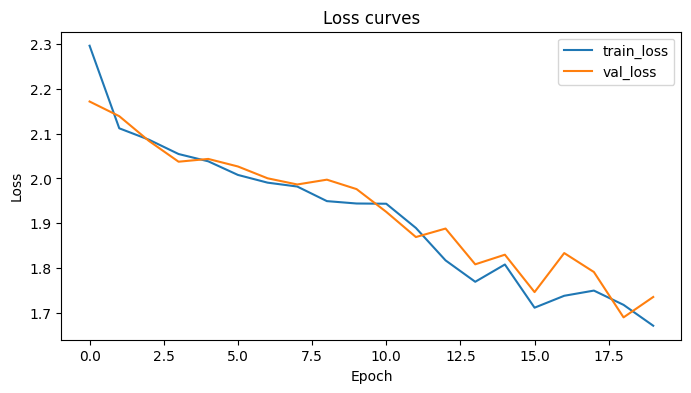

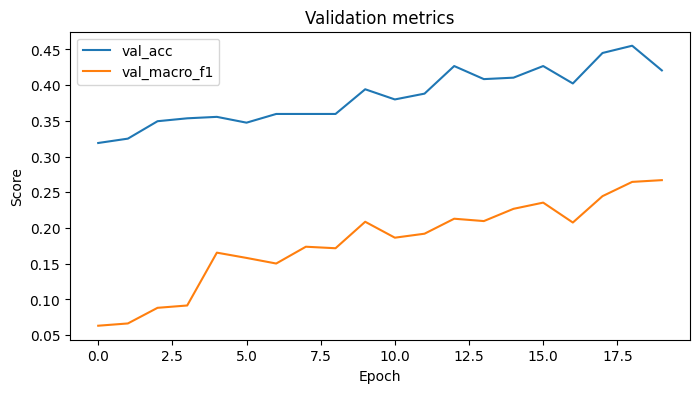

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["val_acc"], label="val_acc")
plt.plot(history["val_f1"], label="val_macro_f1")
plt.legend()
plt.title("Validation metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.show()

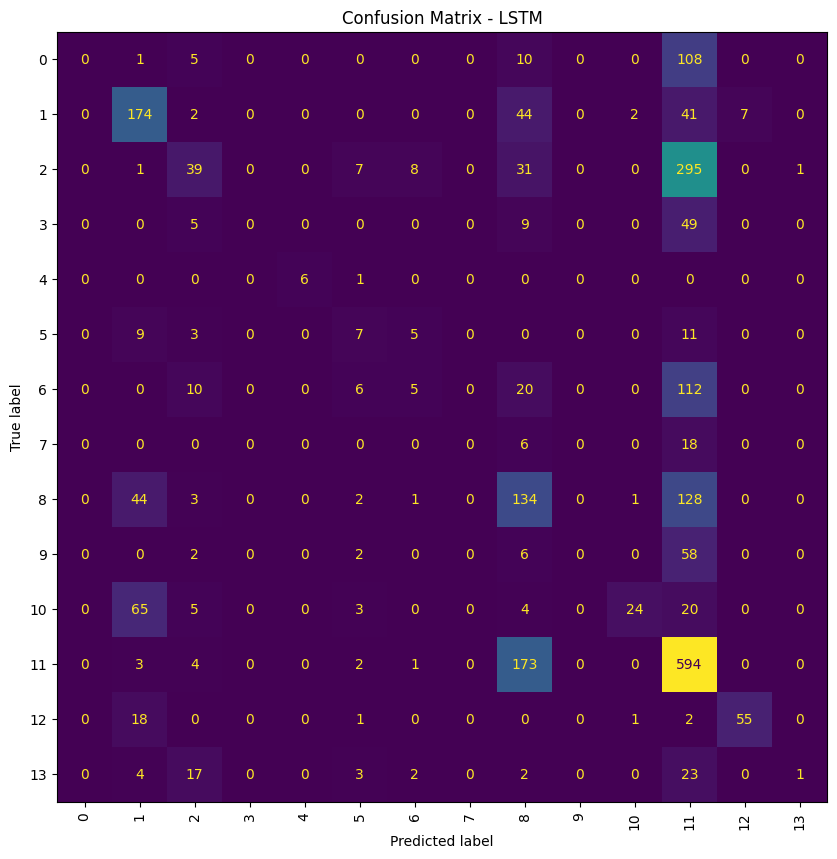

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix - LSTM")
plt.show()